In [1]:
# Import the libraries I will use for data manipulation and model evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import the tools I need to split and preprocess the dataset
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_extraction import DictVectorizer

# Import Logistic Regression for the classification model
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics for ROC AUC, precision, and recall
from sklearn.metrics import roc_auc_score, precision_score, recall_score

In [2]:
# Define the URL of the 2026 lead scoring dataset provided for this homework
data_url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(data_url)

# Display the first five rows to understand the structure of the dataset
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [3]:
# Check the number of rows and columns in the dataset
df.shape

(5000, 9)

In [4]:
# Check the column names and data types before preprocessing
df.dtypes

,0
lead_source,object
industry,object
employment_status,object
location,object
annual_income,float64
number_of_courses_viewed,int64
interaction_count,int64
lead_score,float64
converted,int64


In [5]:
# Check how many missing values exist in each column
df.isnull().sum()

,0
lead_source,148
industry,240
employment_status,194
location,208
annual_income,369
number_of_courses_viewed,0
interaction_count,0
lead_score,35
converted,0


In [6]:
# Identify categorical and numerical columns so I can handle missing values according to their data types
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['number']).columns

# Fill missing categorical values with 'NA'
df[categorical_columns] = df[categorical_columns].fillna('NA')

# Fill missing numerical values with 0.0
df[numerical_columns] = df[numerical_columns].fillna(0.0)

# Verify that there are no missing values left in the dataset
df.isnull().sum()

,0
lead_source,0
industry,0
employment_status,0
location,0
annual_income,0
number_of_courses_viewed,0
interaction_count,0
lead_score,0
converted,0


In [7]:
# Split the dataset into full training and test sets using the exact parameters required in the homework
df_full_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=1
)

# Split the full training set into training and validation sets
df_train, df_val = train_test_split(
    df_full_train,
    test_size=0.25,
    random_state=1
)

# Reset the indexes to keep all datasets clean and consistent
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Check the size of each dataset after splitting
len(df_train), len(df_val), len(df_test)

(3000, 1000, 1000)

In [8]:
# Extract the target variable from each dataset because 'converted' is the value I want the model to predict
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

# Remove the target column from the feature datasets to prevent target leakage during model training
del df_train['converted']
del df_val['converted']
del df_test['converted']

In [9]:
# Check the shapes of the feature and target datasets to make sure the target was separated correctly
df_train.shape, df_val.shape, df_test.shape, y_train.shape, y_val.shape, y_test.shape

((3000, 8), (1000, 8), (1000, 8), (3000,), (1000,), (1000,))

Question 1 — ROC AUC Feature Importance

In [10]:
# Define the numerical features listed in Question 1 so I can evaluate their individual predictive power using ROC AUC
numerical_features = [
    'lead_score',
    'number_of_courses_viewed',
    'interaction_count',
    'annual_income'
]

In [11]:
# Calculate the ROC AUC score for each numerical feature using the training target as the ground truth
for feature in numerical_features:
    auc = roc_auc_score(y_train, df_train[feature])

    # If the AUC is below 0.5, reverse the feature direction because this indicates a negative relationship with the target
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[feature])

    print(f"{feature}: {auc:.4f}")

lead_score: 0.7882
number_of_courses_viewed: 0.7230
interaction_count: 0.7649
annual_income: 0.6082


In [12]:
# Store the adjusted AUC scores so I can identify which numerical feature has the highest ROC AUC
auc_scores = {}

for feature in numerical_features:
    auc = roc_auc_score(y_train, df_train[feature])

    # Reverse the score when the original AUC is below 0.5
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[feature])

    auc_scores[feature] = auc

# Find the feature with the highest adjusted ROC AUC
best_feature = max(auc_scores, key=auc_scores.get)

print("AUC scores:")
for feature, auc in auc_scores.items():
    print(f"{feature}: {auc:.4f}")

print(f"\nFeature with the highest AUC: {best_feature}")
print(f"Highest AUC: {auc_scores[best_feature]:.4f}")

AUC scores:
lead_score: 0.7882
number_of_courses_viewed: 0.7230
interaction_count: 0.7649
annual_income: 0.6082

Feature with the highest AUC: lead_score
Highest AUC: 0.7882


| Feature | ROC AUC |
|---|---:|
| `lead_score` | **0.7882** |
| `interaction_count` | 0.7649 |
| `number_of_courses_viewed` | 0.7230 |
| `annual_income` | 0.6082 |

Question 2 — Training the Model

In [13]:
# Convert each training row into a dictionary so I can use DictVectorizer for one-hot encoding
train_dicts = df_train.to_dict(orient='records')

# Initialize DictVectorizer without creating a sparse matrix to make the transformed feature matrix easier to inspect
dv = DictVectorizer(sparse=False)

# Learn the feature mappings from the training data and transform categorical variables using one-hot encoding
X_train = dv.fit_transform(train_dicts)

# Check the shape of the transformed training matrix
X_train.shape

(3000, 28)

In [14]:
# Check the feature names created by DictVectorizer after applying one-hot encoding
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=retail',
       'industry=technology', 'interaction_count', 'lead_score',
       'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=europe',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [15]:
# Initialize the Logistic Regression model using the exact parameters specified in the homework
model = LogisticRegression(
    solver='liblinear',
    C=1.0,
    max_iter=1000
)

# Train the model using the transformed training data
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [16]:
# Check the intercept learned by the Logistic Regression model
model.intercept_[0]

np.float64(-0.09288149430633613)

In [17]:
# Convert each validation row into a dictionary using the same structure as the training data
val_dicts = df_val.to_dict(orient='records')

# Transform the validation data using the DictVectorizer that was already fitted on the training dataset
X_val = dv.transform(val_dicts)

# Check the shape of the transformed validation matrix
X_val.shape

(1000, 28)

In [18]:
# Predict the probability of conversion for each validation observation and keep the probability for the positive class only
y_pred = model.predict_proba(X_val)[:, 1]

# Display the first ten predicted probabilities
y_pred[:10]

array([0.54472295, 0.79005207, 0.50977909, 0.52913949, 0.82072027,
       0.54246   , 0.50178717, 0.54698398, 0.82553299, 0.40583754])

In [19]:
# Calculate ROC AUC on the validation dataset to evaluate how well the model ranks converted leads
auc = roc_auc_score(y_val, y_pred)

# Display both the exact score and the value rounded to three decimal places as requested in the homework
print(f"Validation ROC AUC: {auc:.6f}")
print(f"Validation ROC AUC (rounded): {auc:.3f}")

Validation ROC AUC: 0.731822
Validation ROC AUC (rounded): 0.732


Question 3 — Precision & Recall

In [20]:
# Create thresholds from 0.00 to 1.00 with a step of 0.01
thresholds = np.arange(0.0, 1.01, 0.01)

# Create an empty list to store precision and recall values calculated for each threshold
scores = []

# Evaluate the model at every threshold
for threshold in thresholds:

    # Convert predicted probabilities into binary predictions
    y_pred_binary = (y_pred >= threshold)

    # Calculate the confusion matrix components
    tp = ((y_pred_binary == 1) & (y_val == 1)).sum()
    fp = ((y_pred_binary == 1) & (y_val == 0)).sum()
    fn = ((y_pred_binary == 0) & (y_val == 1)).sum()

    # Calculate precision while avoiding division by zero
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    # Calculate recall while avoiding division by zero
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    # Store the results for this threshold
    scores.append((threshold, precision, recall))

In [21]:
# Convert the threshold results into a DataFrame so I can inspect and analyze them more easily
df_scores = pd.DataFrame(
    scores,
    columns=['threshold', 'precision', 'recall']
)

# Display the first ten rows
df_scores.head(10)

,threshold,precision,recall
0,0.00,0.586,1.0
1,0.01,0.586,1.0
2,0.02,0.586,1.0
3,0.03,0.586,1.0
4,0.04,0.586,1.0
5,0.05,0.586,1.0
6,0.06,0.586,1.0
7,0.07,0.586,1.0
8,0.08,0.586,1.0
9,0.09,0.586,1.0


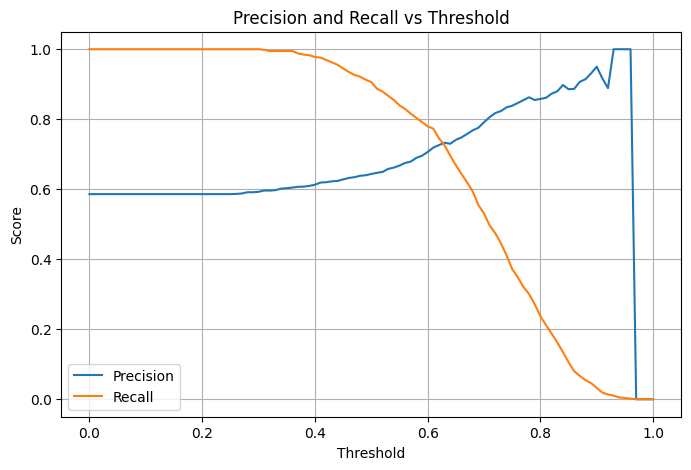

In [22]:
# Plot precision and recall across all evaluated thresholds to see how both metrics change as the decision threshold increases
plt.figure(figsize=(8, 5))

plt.plot(
    df_scores.threshold,
    df_scores.precision,
    label='Precision'
)

plt.plot(
    df_scores.threshold,
    df_scores.recall,
    label='Recall'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid()

plt.show()

In [23]:
# Remove thresholds where both precision and recall are zero because the homework explicitly asks me to ignore these cases
df_nonzero = df_scores[
    ~((df_scores.precision == 0) & (df_scores.recall == 0))
].copy()

# Calculate the absolute difference between precision and recall
df_nonzero['difference'] = abs(
    df_nonzero.precision - df_nonzero.recall
)

# Find the row where precision and recall are closest
best_row = df_nonzero.loc[df_nonzero.difference.idxmin()]

print(f"Threshold: {best_row['threshold']:.2f}")
print(f"Precision: {best_row['precision']:.4f}")
print(f"Recall: {best_row['recall']:.4f}")
print(f"Absolute difference: {best_row['difference']:.6f}")

Threshold: 0.63
Precision: 0.7328
Recall: 0.7253
Absolute difference: 0.007503


Question 4 — F1 Score

In [24]:
# Calculate the F1 score for each threshold by combining precision and recall into a single metric
df_scores['f1'] = np.where(
    (df_scores.precision + df_scores.recall) > 0,
    2 * df_scores.precision * df_scores.recall /
    (df_scores.precision + df_scores.recall),
    0
)

# Display the first ten rows to inspect the calculated F1 scores
df_scores.head(10)

,threshold,precision,recall,f1
0,0.00,0.586,1.0,0.738966
1,0.01,0.586,1.0,0.738966
2,0.02,0.586,1.0,0.738966
3,0.03,0.586,1.0,0.738966
4,0.04,0.586,1.0,0.738966
5,0.05,0.586,1.0,0.738966
6,0.06,0.586,1.0,0.738966
7,0.07,0.586,1.0,0.738966
8,0.08,0.586,1.0,0.738966
9,0.09,0.586,1.0,0.738966


In [25]:
# Find the row with the maximum F1 score to determine the best threshold according to this metric
best_f1_row = df_scores.loc[df_scores.f1.idxmax()]

# Display the threshold and its corresponding metrics
print(f"Threshold: {best_f1_row['threshold']:.2f}")
print(f"Precision: {best_f1_row['precision']:.4f}")
print(f"Recall: {best_f1_row['recall']:.4f}")
print(f"F1 score: {best_f1_row['f1']:.4f}")

Threshold: 0.41
Precision: 0.6190
Recall: 0.9761
F1 score: 0.7576


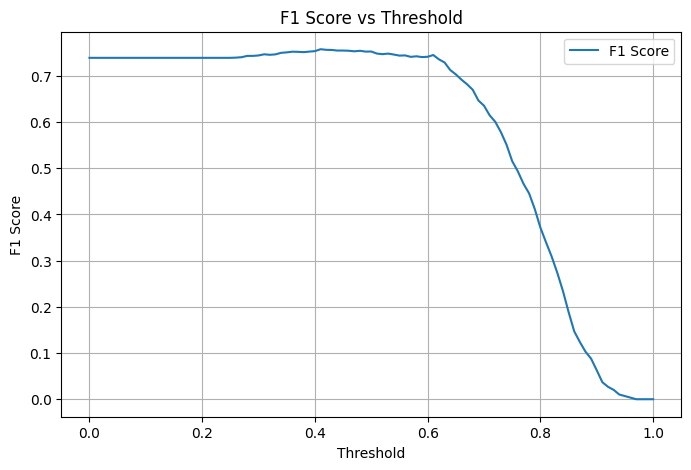

In [26]:
# Plot the F1 score across all thresholds to visualize where the model achieves its maximum F1 score
plt.figure(figsize=(8, 5))

plt.plot(
    df_scores.threshold,
    df_scores.f1,
    label='F1 Score'
)

plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.grid()

plt.show()

Question 5 — 5-Fold Cross-Validation

In [27]:
# Create a reusable function to train the Logistic Regression model so I can apply the same training process to every cross-validation fold
def train(df_train, y_train, C=1.0):

    # Convert the training DataFrame into dictionaries
    train_dicts = df_train.to_dict(orient='records')

    # Create and fit DictVectorizer on the current training fold
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(train_dicts)

    # Create the Logistic Regression model
    # using the parameters required in the homework
    model = LogisticRegression(
        solver='liblinear',
        C=C,
        max_iter=1000
    )

    # Train the model on the current fold
    model.fit(X_train, y_train)

    # Return both objects because I will need
    # the fitted vectorizer when making predictions
    return dv, model

In [28]:
# Create a reusable function to generate probabilities using the vectorizer and model fitted on the training fold
def predict(df, dv, model):

    # Convert the DataFrame into dictionaries
    dicts = df.to_dict(orient='records')

    # Transform the data using the already fitted vectorizer
    X = dv.transform(dicts)

    # Predict the probability of the positive class
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [29]:
# Check that the target column is still available in the full training dataset before cross-validation
df_full_train.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='object')

In [30]:
# Reset the index of the full training dataset before generating the cross-validation folds
df_full_train = df_full_train.reset_index(drop=True)

In [31]:
# Initialize 5-fold cross-validation using the exact parameters specified in the homework
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

# Create an empty list to store the AUC score from each fold
auc_scores = []

# Iterate through all five train-validation splits
for fold, (train_idx, val_idx) in enumerate(kfold.split(df_full_train), start=1):

    # Select the training and validation parts for the current fold
    df_train_fold = df_full_train.iloc[train_idx].copy()
    df_val_fold = df_full_train.iloc[val_idx].copy()

    # Extract the target variable from both folds
    y_train_fold = df_train_fold.converted.values
    y_val_fold = df_val_fold.converted.values

    # Remove the target column from the feature datasets
    del df_train_fold['converted']
    del df_val_fold['converted']

    # Train the model on the current training fold
    dv_fold, model_fold = train(
        df_train_fold,
        y_train_fold,
        C=1.0
    )

    # Generate probabilities for the current validation fold
    y_pred_fold = predict(
        df_val_fold,
        dv_fold,
        model_fold
    )

    # Calculate ROC AUC for the current fold
    auc = roc_auc_score(y_val_fold, y_pred_fold)

    # Store the score for the final calculation
    auc_scores.append(auc)

    print(f"Fold {fold} AUC: {auc:.4f}")

Fold 1 AUC: 0.7306
Fold 2 AUC: 0.7296
Fold 3 AUC: 0.7363
Fold 4 AUC: 0.7412
Fold 5 AUC: 0.7209


In [32]:
# Calculate the mean and standard deviation of the ROC AUC scores across all five folds
mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores)

print(f"\nMean AUC: {mean_auc:.4f}")
print(f"Standard deviation: {std_auc:.4f}")
print(f"Standard deviation (3 decimals): {std_auc:.3f}")


Mean AUC: 0.7317
Standard deviation: 0.0069
Standard deviation (3 decimals): 0.007


Question 6 — Hyperparameter Tuning

In [33]:
# Define the C values specified in the homework to compare different levels of regularization
C_values = [0.000001, 0.001, 1]

# Create an empty list to store the cross-validation results
cv_results = []

# Evaluate each C value using the same 5-fold cross-validation setup
for C in C_values:

    # Initialize KFold with the exact parameters required in the homework
    kfold = KFold(
        n_splits=5,
        shuffle=True,
        random_state=1
    )

    # Store the AUC scores obtained for the current C value
    fold_scores = []

    # Iterate through all five folds
    for train_idx, val_idx in kfold.split(df_full_train):

        # Create the training and validation folds
        df_train_fold = df_full_train.iloc[train_idx].copy()
        df_val_fold = df_full_train.iloc[val_idx].copy()

        # Extract the target variable from each fold
        y_train_fold = df_train_fold.converted.values
        y_val_fold = df_val_fold.converted.values

        # Remove the target column from the feature datasets
        del df_train_fold['converted']
        del df_val_fold['converted']

        # Train Logistic Regression using the current C value
        dv_fold, model_fold = train(
            df_train_fold,
            y_train_fold,
            C=C
        )

        # Generate conversion probabilities for the validation fold
        y_pred_fold = predict(
            df_val_fold,
            dv_fold,
            model_fold
        )

        # Calculate ROC AUC for the current validation fold
        auc = roc_auc_score(y_val_fold, y_pred_fold)

        # Store the AUC score
        fold_scores.append(auc)

    # Calculate mean AUC and standard deviation across the five folds
    mean_auc = np.mean(fold_scores)
    std_auc = np.std(fold_scores)

    # Store the results for comparison
    cv_results.append((C, mean_auc, std_auc))

    print(
        f"C={C:<8} "
        f"Mean AUC={mean_auc:.3f} "
        f"Std={std_auc:.3f}"
    )

C=1e-06    Mean AUC=0.617 Std=0.019
C=0.001    Mean AUC=0.749 Std=0.010
C=1        Mean AUC=0.732 Std=0.007


In [34]:
# Convert the cross-validation results into a DataFrame so I can compare the tested C values more clearly
df_cv_results = pd.DataFrame(
    cv_results,
    columns=['C', 'mean_auc', 'std_auc']
)

# Round the mean AUC and standard deviation to three decimal places as requested in the homework
df_cv_results['mean_auc_rounded'] = df_cv_results['mean_auc'].round(3)
df_cv_results['std_auc_rounded'] = df_cv_results['std_auc'].round(3)

df_cv_results

,C,mean_auc,std_auc,mean_auc_rounded,std_auc_rounded
0,0.000001,0.616734,0.018670,0.617,0.019
1,0.001000,0.749172,0.009996,0.749,0.010
2,1.000000,0.731727,0.006853,0.732,0.007


In [35]:
# Sort the results according to the homework rules:
# 1. Highest rounded mean AUC
# 2. Lowest rounded standard deviation in case of a tie
# 3. Smallest C if the tie still remains
best_result = df_cv_results.sort_values(
    by=['mean_auc_rounded', 'std_auc_rounded', 'C'],
    ascending=[False, True, True]
).iloc[0]

print(f"Best C: {best_result['C']}")
print(f"Mean AUC: {best_result['mean_auc_rounded']:.3f}")
print(f"Standard deviation: {best_result['std_auc_rounded']:.3f}")

Best C: 0.001
Mean AUC: 0.749
Standard deviation: 0.010


In [36]:
# Final answers for Homework 4
# These results are based on the calculations performed throughout the notebook

answers = {
    "Question 1": "lead_score",
    "Question 2": 0.732,
    "Question 3": 0.63,
    "Question 4": 0.41,
    "Question 5": 0.007,
    "Question 6": 0.001
}

# Display all final homework answers
for question, answer in answers.items():
    print(f"{question}: {answer}")

Question 1: lead_score
Question 2: 0.732
Question 3: 0.63
Question 4: 0.41
Question 5: 0.007
Question 6: 0.001


## Homework 4 - Summary

In this homework, I evaluated a Logistic Regression model for predicting lead conversion.

I first analyzed the numerical features individually using ROC AUC and found that `lead_score` had the highest predictive power.

After applying one-hot encoding with `DictVectorizer`, I trained a Logistic Regression model and evaluated it on the validation dataset.

I then analyzed the effect of different classification thresholds using precision, recall, and F1 score.

Finally, I used 5-fold cross-validation to evaluate the stability of the model and performed hyperparameter tuning for the regularization parameter `C`.

### Final Answers

- Question 1: `lead_score`
- Question 2: `0.732`
- Question 3: `0.63`
- Question 4: `0.41`
- Question 5: `0.007`
- Question 6: `0.001`